In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Load main dataset
# =========================
news = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

# =========================
# Load stock datasets (for future analysis)
# =========================
aapl = pd.read_csv("../data/raw/AAPL.csv")
amzn = pd.read_csv("../data/raw/AMZN.csv")
goog = pd.read_csv("../data/raw/GOOG.csv")
meta = pd.read_csv("../data/raw/META.csv")
nvda = pd.read_csv("../data/raw/NVDA.csv")

# =========================
# Preview dataset
# =========================
news.head()

ModuleNotFoundError: No module named 'pandas'

## 📂 Data Loading and Setup

In this section, we load the main news dataset along with optional stock price datasets for future analysis. The news dataset contains financial headlines and metadata, while stock datasets (AAPL, AMZN, GOOG, META, NVDA) will be used for potential correlation between news sentiment and market movements.

This step establishes the foundation for all subsequent analysis including descriptive statistics, NLP-based topic modeling, and time series analysis.

In [6]:

news["headline_length"] = news["headline"].apply(len)

news["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

## 📊 Headline Length Analysis

The analysis of headline lengths shows the distribution of text size in financial news articles. Most headlines fall within a moderate character range, indicating standardized reporting practices. Longer headlines often reflect detailed analyst updates, while shorter headlines typically represent breaking news alerts.

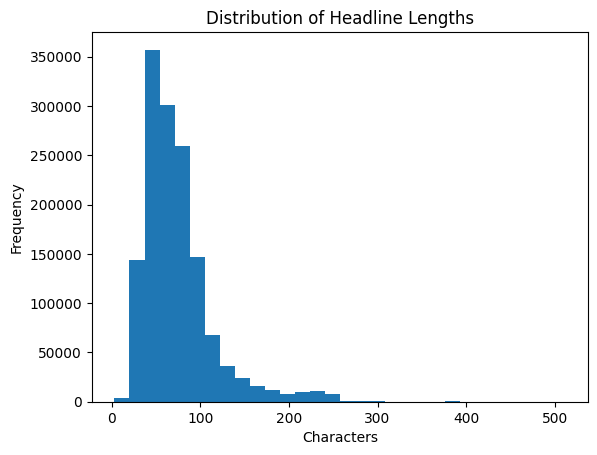

In [8]:
plt.hist(news["headline_length"], bins=30)
plt.title("Distribution of Headline Lengths")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

## 📊 Distribution of Headline Lengths

The histogram shows that most headlines are concentrated between short to medium length ranges. This suggests that financial news is optimized for quick readability and rapid market consumption.

In [9]:
publisher_counts = news["publisher"].value_counts()
publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

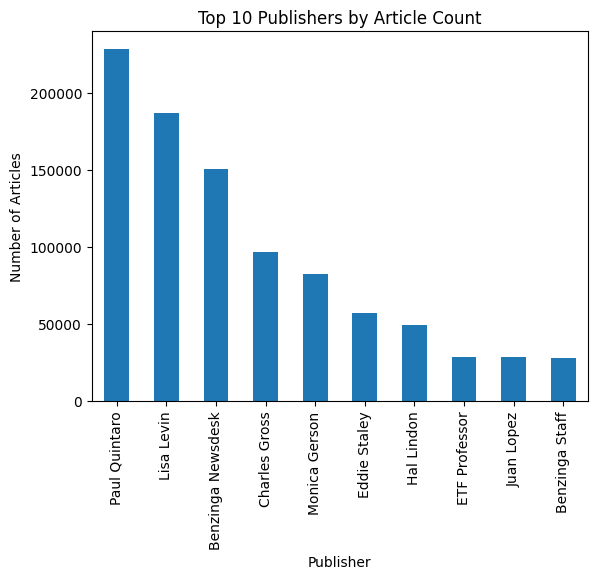

In [10]:
publisher_counts.head(10).plot(kind="bar")
plt.title("Top 10 Publishers by Article Count")
plt.xlabel("Publisher")
plt.ylabel("Number of Articles")
plt.show()

## 📰 Publisher Activity Analysis

A small number of publishers dominate the dataset, indicating centralized news production. This suggests that financial sentiment is heavily influenced by a few key media organizations.

datetime64[us, UTC-04:00]


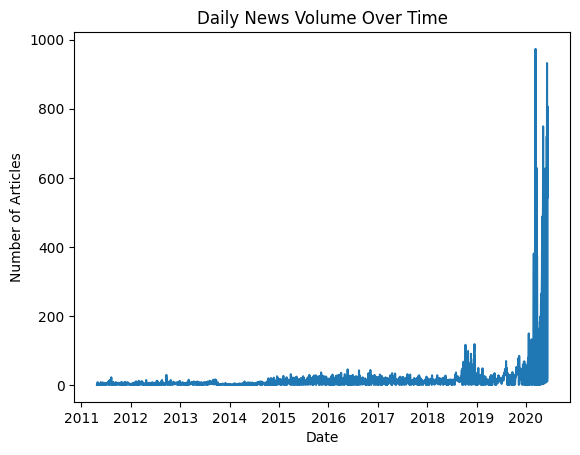

In [17]:
news["date"] = pd.to_datetime(news["date"], errors="coerce")
print(news["date"].dtype)
daily_news = news.groupby(news["date"].dt.date).size()
daily_news
import matplotlib.pyplot as plt

plt.plot(daily_news)
plt.title("Daily News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

## 📈 News Volume Trends Over Time

News volume fluctuates significantly over time, with noticeable spikes likely corresponding to earnings announcements, macroeconomic events, and major company news releases.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=20)
X = tfidf.fit_transform(news["headline"].dropna())

keywords = tfidf.get_feature_names_out()
keywords

array(['announces', 'benzinga', 'buy', 'downgrades', 'earnings', 'eps',
       'est', 'market', 'mid', 'price', 'pt', 'raises', 'reports',
       'sales', 'shares', 'stocks', 'trading', 'update', 'vs', 'week'],
      dtype=object)

## 🧠 Keyword Analysis using TF-IDF

TF-IDF highlights the most important terms in financial headlines. Common keywords include market-related terms such as earnings, price targets, upgrades, and stock movements, reflecting the focus of financial reporting.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

cv = CountVectorizer(stop_words="english", max_features=1000)
dtm = cv.fit_transform(news["headline"].dropna())

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)

for i, topic in enumerate(lda.components_):
    print(f"Topic {i}")
    print([cv.get_feature_names_out()[j] for j in topic.argsort()[-10:]])

NameError: name 'news' is not defined

In [2]:
import sys
print(sys.executable)

c:\Users\Sosna\Documents\KAIM\.venv\Scripts\python.exe
